0. 환경설정

In [41]:
# 필요한 패키지 설치
!pip install -q transformers accelerate sentencepiece evaluate rouge_score sentence-transformers sacrebleu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 6.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchvision 0.26.0+cu128 requires torch==2.11.0, but you have torch 2.13.0 which is incompatible.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
cudf-cu12 26.2.1 requires cuda-toolkit[nvcc,nvrtc]==12.*, but you have cuda-toolkit 13.0.3.0 which is incompatible.


In [42]:
from google.colab import drive
drive.mount('/content/drive')

import os

# 체크포인트/결과 저장 루트 (원하는 경로로 수정 가능)
PROJECT_DIR = '/content/drive/MyDrive/KoChatGPT_upgrade'
os.makedirs(PROJECT_DIR, exist_ok=True)
CHECKPOINT_PATH = os.path.join(PROJECT_DIR, 'checkpoint.json')
print('체크포인트 저장 경로:', CHECKPOINT_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
체크포인트 저장 경로: /content/drive/MyDrive/KoChatGPT_upgrade/checkpoint.json


In [43]:
print(repr(PROJECT_DIR))
print('폴더 존재 여부:', os.path.isdir(PROJECT_DIR))

'/content/drive/MyDrive/KoChatGPT_upgrade'
폴더 존재 여부: True


1. 작업 기억

In [44]:
import json
from datetime import datetime

def load_checkpoint():
    """저장된 체크포인트를 불러온다. 없으면 빈 상태로 시작."""
    if os.path.exists(CHECKPOINT_PATH):
        with open(CHECKPOINT_PATH, 'r', encoding='utf-8') as f:
            state = json.load(f)
        print(f"[체크포인트 로드 완료] 마지막 저장 시각: {state.get('last_saved', '알 수 없음')}")
        print(f"완료된 단계: {state.get('completed_stages', [])}")
        return state
    else:
        print('[체크포인트 없음] 새로운 작업을 시작합니다.')
        return {
            'completed_stages': [],   # 완료된 큰 단계 이름 리스트
            'generations': {},         # {technique_name: {question: answer, ...}, ...}
            'metrics': {},             # {technique_name: {metric_name: value, ...}, ...}
            'last_saved': None,
        }

def save_checkpoint(state):
    """현재 상태를 즉시 Drive에 저장한다. 각 작업 단위(질문 1개, 기법 1개)가 끝날 때마다 호출."""
    state['last_saved'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    with open(CHECKPOINT_PATH, 'w', encoding='utf-8') as f:
        json.dump(state, f, ensure_ascii=False, indent=2)

def mark_stage_done(state, stage_name):
    if stage_name not in state['completed_stages']:
        state['completed_stages'].append(stage_name)
    save_checkpoint(state)
    print(f"[단계 완료 및 저장] {stage_name}")

# 상태 불러오기 (런타임 재시작 시 이 셀부터 다시 실행하면 자동 복구됨)
state = load_checkpoint()

[체크포인트 로드 완료] 마지막 저장 시각: 2026-07-22 04:37:56
완료된 단계: ['sft_training', 'generation', 'metrics', 'sft_vs_base_comparison']


2. 모델로드

In [45]:
import os

# KoChatGPT 관련 폴더를 통째로 훑어보기
base = '/content/drive/MyDrive'
for root, dirs, files in os.walk(base):
    if 'KoChatGPT' in root:
        print(root, '->', files[:5])

/content/drive/MyDrive/KoChatGPT_upgrade -> ['metric_comparison.csv', 'checkpoint.json', 'metric_comparison.png']
/content/drive/MyDrive/KoChatGPT_upgrade/sft_trainer_raw_output -> []
/content/drive/MyDrive/KoChatGPT_upgrade/sft_trainer_raw_output/checkpoint-1400 -> ['config.json', 'generation_config.json', 'model.safetensors', 'tokenizer_config.json', 'tokenizer.json']
/content/drive/MyDrive/KoChatGPT_upgrade/sft_trainer_raw_output/checkpoint-1500 -> ['config.json', 'generation_config.json', 'model.safetensors', 'tokenizer_config.json', 'tokenizer.json']
/content/drive/MyDrive/KoChatGPT_upgrade/output_1_SFT -> ['config.json', 'generation_config.json', 'model.safetensors', 'training_args.bin', 'tokenizer_config.json']


In [46]:
import os

base = '/content/drive/MyDrive'
for root, dirs, files in os.walk(base):
    # config.json이 있으면 학습된 모델 폴더일 가능성이 높음
    if 'config.json' in files or 'pytorch_model.bin' in files or 'model.safetensors' in files:
        print('모델로 추정되는 폴더:', root)

모델로 추정되는 폴더: /content/drive/MyDrive/KoChatGPT_upgrade/sft_trainer_raw_output/checkpoint-1400
모델로 추정되는 폴더: /content/drive/MyDrive/KoChatGPT_upgrade/sft_trainer_raw_output/checkpoint-1500
모델로 추정되는 폴더: /content/drive/MyDrive/KoChatGPT_upgrade/output_1_SFT


- Drive에 저장된 SFT 모델이 없는것을 확인

3. SFT 모델 직접 학습

In [1]:
# 원본 리포지토리 clone (SFT 학습 데이터, 프롬프트 템플릿 포함)
!git clone -q https://github.com/airobotlab/KoChatGPT.git
!cp -r KoChatGPT/data_kochatgpt ./data_kochatgpt
print('데이터 준비 완료')

데이터 준비 완료


In [48]:
!pip install -q --force-reinstall transformers==4.44.2 tokenizers==0.19.1 accelerate==0.34.2

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.6.0 which is incompatible.
torchvision 0.26.0+cu128 requires torch==2.11.0, but you have torch 2.13.0 which is incompatible.
cuda-python 12.9.7 requires cuda-bindings~=12.9.7, but you have cuda-bindings 13.3.1 which is incompatible.
cuml-cu12 26.2.0 requires cuda-toolkit[cublas,cufft,curand,cusolver,cusparse]==12.*, but you have cuda-toolkit 13.0.3.0 which is incompatible.
libraft-cu12 26.2.0 requires cuda-toolkit[cublas,curand,cusolver,cusparse]==12.*, but you have cuda-toolkit 13.0.3.0 which is incompatible.
libcuml-cu12 26.2.0 requires cuda-toolkit[cublas,cufft,curand,cusol

In [2]:
import torch
print('torch 버전:', torch.__version__)
print('CUDA 사용 가능:', torch.cuda.is_available())

torch 버전: 2.11.0+cu128
CUDA 사용 가능: True


In [3]:
import sys
!{sys.executable} -m pip install -q transformers==4.44.2 tokenizers==0.19.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 75.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 19.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [5]:
import transformers
print('transformers 버전:', transformers.__version__)

transformers 버전: 4.44.2


In [6]:
from transformers import AutoTokenizer

raw_tok = AutoTokenizer.from_pretrained('skt/kogpt2-base-v2')
print('영어:', raw_tok.decode(raw_tok.encode("Hello world")))
print('한국어:', raw_tok.decode(raw_tok.encode("안녕하세요. 오늘 날씨가 좋네요.")))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


영어: Hello world
한국어: 안녕하세요. 오늘 날씨가 좋네요.


In [7]:
from google.colab import drive
drive.mount('/content/drive')

import os

PROJECT_DIR = '/content/drive/MyDrive/KoChatGPT_upgrade'
os.makedirs(PROJECT_DIR, exist_ok=True)
CHECKPOINT_PATH = os.path.join(PROJECT_DIR, 'checkpoint.json')
print('체크포인트 저장 경로:', CHECKPOINT_PATH)

Mounted at /content/drive
체크포인트 저장 경로: /content/drive/MyDrive/KoChatGPT_upgrade/checkpoint.json


In [8]:
import json
from datetime import datetime

def load_checkpoint():
    """저장된 체크포인트를 불러온다. 없으면 빈 상태로 시작."""
    if os.path.exists(CHECKPOINT_PATH):
        with open(CHECKPOINT_PATH, 'r', encoding='utf-8') as f:
            state = json.load(f)
        print(f"[체크포인트 로드 완료] 마지막 저장 시각: {state.get('last_saved', '알 수 없음')}")
        print(f"완료된 단계: {state.get('completed_stages', [])}")
        return state
    else:
        print('[체크포인트 없음] 새로운 작업을 시작합니다.')
        return {
            'completed_stages': [],
            'generations': {},
            'metrics': {},
            'last_saved': None,
        }

def save_checkpoint(state):
    """현재 상태를 즉시 Drive에 저장한다."""
    state['last_saved'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    with open(CHECKPOINT_PATH, 'w', encoding='utf-8') as f:
        json.dump(state, f, ensure_ascii=False, indent=2)

def mark_stage_done(state, stage_name):
    if stage_name not in state['completed_stages']:
        state['completed_stages'].append(stage_name)
    save_checkpoint(state)
    print(f"[단계 완료 및 저장] {stage_name}")

state = load_checkpoint()

[체크포인트 로드 완료] 마지막 저장 시각: 2026-07-22 04:37:56
완료된 단계: ['sft_training', 'generation', 'metrics', 'sft_vs_base_comparison']


In [9]:
sample_q = list(state['generations']['baseline'].keys())[0]
print('질문:', sample_q)
print('저장된 baseline 답변:', state['generations']['baseline'][sample_q])

질문: 건강하게 살을 빼는 방법을 알려줘.
저장된 baseline 답변: ��������������.\'��AI������������������������,�������������������.�����������������������������.


In [10]:
# 깨진 상태로 저장된 generation, metrics 결과 초기화 (모델 재학습은 필요 없음)
state['generations'] = {}
state['metrics'] = {}
state['completed_stages'] = [s for s in state['completed_stages'] if s not in ('generation', 'metrics', 'sft_vs_base_comparison')]
save_checkpoint(state)
print('초기화 완료. 남은 완료 단계:', state['completed_stages'])

초기화 완료. 남은 완료 단계: ['sft_training']


In [11]:
import os

BASE_MODEL_NAME = 'skt/kogpt2-base-v2'
PROJECT_DIR = '/content/drive/MyDrive/KoChatGPT_upgrade'
SFT_MODEL_PATH = os.path.join(PROJECT_DIR, 'output_1_SFT')

print('SFT_MODEL_PATH:', SFT_MODEL_PATH)
print('폴더 존재 여부:', os.path.isdir(SFT_MODEL_PATH))

SFT_MODEL_PATH: /content/drive/MyDrive/KoChatGPT_upgrade/output_1_SFT
폴더 존재 여부: True


In [12]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('사용 device:', device)

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_NAME)
tokenizer.add_special_tokens({
    "eos_token": "</s>", "bos_token": "</s>", "unk_token": "</s>",
})
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(SFT_MODEL_PATH).to(device)
model.resize_token_embeddings(len(tokenizer))
model.eval()

test = "안녕하세요. 오늘 날씨가 좋네요."
print('왕복 테스트:', tokenizer.decode(tokenizer.encode(test)))
print('SFT 모델 로드 완료')

사용 device: cuda


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


왕복 테스트: 안녕하세요. 오늘 날씨가 좋네요.
SFT 모델 로드 완료


In [13]:
inputs = tokenizer("건강하게 살을 빼는 방법을 알려줘.", return_tensors='pt').to(device)
with torch.no_grad():
    output = model.generate(
        **inputs,
        max_new_tokens=100,
        do_sample=True,
        top_k=50,
        top_p=0.95,
        temperature=0.8,
        repetition_penalty=1.2,
        pad_token_id=tokenizer.pad_token_id,
    )
print(tokenizer.decode(output[0], skip_special_tokens=True))

건강하게 살을 빼는 방법을 알려줘.


In [14]:
print('길이:', len(output[0]))
print('토큰 id:', output[0].tolist())
print('---')
print('special token 포함:', tokenizer.decode(output[0], skip_special_tokens=False))

길이: 9
토큰 id: [51005, 38551, 11343, 7162, 11683, 9666, 8244, 389, 1]
---
special token 포함: 건강하게 살을 빼는 방법을 알려줘.</s>


In [15]:
PROMPT_NO_INPUT = (
    "Below is an instruction that describes a task.\n"
    "아래는 작업을 설명하는 명령어입니다.\n\n"
    "Write a response that appropriately completes the request.\n명령어에 따른 요청을 적절히 완료하는 응답을 작성하세요.\n\n"
    "### Instruction(명령어):\n{prompt}\n\n### Response(응답):"
)

test_prompt = PROMPT_NO_INPUT.format(prompt="건강하게 살을 빼는 방법을 알려줘.")
inputs = tokenizer(test_prompt, return_tensors='pt').to(device)
with torch.no_grad():
    output = model.generate(
        **inputs,
        max_new_tokens=100,
        do_sample=True,
        top_k=50,
        top_p=0.95,
        temperature=0.8,
        repetition_penalty=1.2,
        pad_token_id=tokenizer.pad_token_id,
    )
print(tokenizer.decode(output[0], skip_special_tokens=True))

Below is an instruction that describes a task.
아래는 작업을 설명하는 명령어입니다.

Write a response that appropriately completes the request.
명령어에 따른 요청을 적절히 완료하는 응답을 작성하세요.

### Instruction(명령어):
건강하게 살을 빼는 방법을 알려줘.

### Response(응답):'ìłê°AIëìëëìíìħëë.ê·êìììłìê±°ì?


In [16]:
import json

with open('./data_kochatgpt/kochatgpt_1_SFT.jsonl', 'r', encoding='utf-8-sig') as f:
    sample_data = json.load(f)[:1]

sample_text = sample_data[0]['completion']
print('원본:', sample_text[:50])

encoded = tokenizer.encode(sample_text)
decoded = tokenizer.decode(encoded)
print('왕복 결과:', decoded[:50])
print('일치 여부:', sample_text[:50] == decoded[:50])

원본: '저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 하지만 일
왕복 결과: '저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 하지만 일
일치 여부: True


In [17]:
import shutil

RAW_TRAINER_OUTPUT = os.path.join(PROJECT_DIR, 'sft_trainer_raw_output')

if os.path.isdir(SFT_MODEL_PATH):
    shutil.rmtree(SFT_MODEL_PATH)
    print('기존 SFT 모델 삭제 완료')

if os.path.isdir(RAW_TRAINER_OUTPUT):
    shutil.rmtree(RAW_TRAINER_OUTPUT)
    print('기존 체크포인트 삭제 완료')

os.makedirs(RAW_TRAINER_OUTPUT, exist_ok=True)
print('정리 완료. 재학습 준비됨.')

기존 SFT 모델 삭제 완료
기존 체크포인트 삭제 완료
정리 완료. 재학습 준비됨.


In [18]:
!git clone -q https://github.com/airobotlab/KoChatGPT.git
!cp -r KoChatGPT/data_kochatgpt ./data_kochatgpt
print('데이터 준비 완료')

fatal: destination path 'KoChatGPT' already exists and is not an empty directory.
데이터 준비 완료


In [19]:
import copy
import logging
from dataclasses import dataclass
from typing import Dict, Sequence
from torch.utils.data import Dataset
import transformers

IGNORE_INDEX = -100
PROMPT_DICT = {
    "prompt_input": (
        "Below is an instruction that describes a task, paired with an input that provides further context.\n"
        "아래는 작업을 설명하는 명령어와 추가적 맥락을 제공하는 입력이 짝을 이루는 예제입니다.\n\n"
        "Write a response that appropriately completes the request.\n요청을 적절히 완료하는 응답을 작성하세요.\n\n"
        "### Instruction(명령어):\n{prompt}\n\n### Input(입력):\n{input}\n\n### Response(응답):"
    ),
    "prompt_no_input": (
        "Below is an instruction that describes a task.\n"
        "아래는 작업을 설명하는 명령어입니다.\n\n"
        "Write a response that appropriately completes the request.\n명령어에 따른 요청을 적절히 완료하는 응답을 작성하세요.\n\n"
        "### Instruction(명령어):\n{prompt}\n\n### Response(응답):"
    ),
}

class SFT_dataset(Dataset):
    def __init__(self, data_path_1_SFT: str, tokenizer, sample_size=None):
        super().__init__()
        with open(data_path_1_SFT, "r", encoding='utf-8-sig') as f:
            list_data_dict = json.load(f)
        if sample_size is not None:
            list_data_dict = list_data_dict[:sample_size]

        prompt_input, prompt_no_input = PROMPT_DICT["prompt_input"], PROMPT_DICT["prompt_no_input"]
        sources = []
        for example in list_data_dict:
            if example.get('input', "") != "":
                sources.append(prompt_input.format_map(example))
            else:
                sources.append(prompt_no_input.format_map(example))
        targets = [f"{example['completion']}{tokenizer.eos_token}" for example in list_data_dict]

        examples = [s + t for s, t in zip(sources, targets)]
        sources_tokenized = self._tokenize_fn(sources, tokenizer)
        examples_tokenized = self._tokenize_fn(examples, tokenizer)

        input_ids = examples_tokenized["input_ids"]
        labels = copy.deepcopy(input_ids)
        for label, source_len in zip(labels, sources_tokenized["input_ids_lens"]):
            label[:source_len] = IGNORE_INDEX

        self.input_ids = input_ids
        self.labels = labels
        print("Loading data done!!:", len(self.labels))

    def _tokenize_fn(self, strings, tokenizer):
        tokenized_list = [
            tokenizer(text, return_tensors="pt", padding="longest",
                       max_length=tokenizer.model_max_length, truncation=True)
            for text in strings
        ]
        input_ids = [t.input_ids[0] for t in tokenized_list]
        input_ids_lens = [t.input_ids.ne(tokenizer.pad_token_id).sum().item() for t in tokenized_list]
        return dict(input_ids=input_ids, input_ids_lens=input_ids_lens)

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, i):
        return dict(input_ids=self.input_ids[i], labels=self.labels[i])


@dataclass
class DataCollatorForSupervisedDataset:
    tokenizer: transformers.PreTrainedTokenizer

    def __call__(self, instances: Sequence[Dict]) -> Dict[str, torch.Tensor]:
        input_ids, labels = tuple([ins[k] for ins in instances] for k in ("input_ids", "labels"))
        input_ids = torch.nn.utils.rnn.pad_sequence(
            input_ids, batch_first=True, padding_value=self.tokenizer.pad_token_id)
        labels = torch.nn.utils.rnn.pad_sequence(labels, batch_first=True, padding_value=IGNORE_INDEX)
        return dict(input_ids=input_ids, labels=labels,
                    attention_mask=input_ids.ne(self.tokenizer.pad_token_id))

print('클래스 정의 완료')

클래스 정의 완료


In [23]:
from transformers import AutoModelForCausalLM, Trainer, TrainingArguments

SAMPLE_SIZE = None
SFT_EPOCHS = 2

sft_base_model = AutoModelForCausalLM.from_pretrained(BASE_MODEL_NAME)
sft_base_model.resize_token_embeddings(len(tokenizer))

train_dataset = SFT_dataset(
    data_path_1_SFT='./data_kochatgpt/kochatgpt_1_SFT.jsonl',
    tokenizer=tokenizer,
    sample_size=SAMPLE_SIZE,
)
data_collator = DataCollatorForSupervisedDataset(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir=RAW_TRAINER_OUTPUT,
    num_train_epochs=SFT_EPOCHS,
    per_device_train_batch_size=8,
    save_strategy="steps",
    save_steps=100,
    save_total_limit=1,
    warmup_steps=5,
    logging_steps=20,
    prediction_loss_only=True,
)

trainer = Trainer(
    model=sft_base_model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=train_dataset,
)

trainer.train(resume_from_checkpoint=None)

trainer.save_model(SFT_MODEL_PATH)
tokenizer.save_pretrained(SFT_MODEL_PATH)
print('[SFT 학습 및 저장 완료]', SFT_MODEL_PATH)

Loading data done!!: 12000


Step,Training Loss
20,3.631400
40,3.304800
60,3.123300
80,3.171700
100,3.049300
120,3.066900
140,3.031300
160,2.852100
180,2.983900
200,3.028300


[SFT 학습 및 저장 완료] /content/drive/MyDrive/KoChatGPT_upgrade/output_1_SFT


4. 학습된 SFT모델 로드

In [24]:
from transformers import AutoModelForCausalLM

model = AutoModelForCausalLM.from_pretrained(SFT_MODEL_PATH).to(device)
model.eval()

inputs = tokenizer("건강하게 살을 빼는 방법을 알려줘.", return_tensors='pt').to(device)
with torch.no_grad():
    output = model.generate(
        **inputs,
        max_new_tokens=100,
        do_sample=True,
        top_k=50,
        top_p=0.95,
        temperature=0.8,
        repetition_penalty=1.2,
        pad_token_id=tokenizer.pad_token_id,
    )
print(tokenizer.decode(output[0], skip_special_tokens=True))

건강하게 살을 빼는 방법을 알려줘.\n\n1. 운동 : 적당한 운동을 하고, 몸을 움직여서 몸의 근육을 강화하며 신진대사를 활성화 시키는 것을 추천합니다.\n2. 취미 생활: 건강한 식습관과 규칙적인 운동, 스트레스 관리 등이 좋은 효과를 줍니다.\n3. 건강 상태 개선: 운동과 충분한 수면, 음주, 흡연, 흡연 등의 질병 예방에 대한 관심과 노력이 필요합니다. 이러한 것들이 건강에 좋다면 적극적으로 시도하고 실천해야 합니다.


5. 전략1: Instruction Tuning / Prompting 기법 적용

In [25]:
def build_prompt(technique, question):
    base_template = (
        "Below is an instruction that describes a task.\n"
        "아래는 작업을 설명하는 명령어입니다.\n\n"
        "Write a response that appropriately completes the request.\n명령어에 따른 요청을 적절히 완료하는 응답을 작성하세요.\n\n"
        "### Instruction(명령어):\n{instruction}\n\n### Response(응답):"
    )

    if technique == 'baseline':
        return base_template.format(instruction=question)

    elif technique == 'zero_shot_instruction':
        return base_template.format(
            instruction="다음 질문에 정확하고 친절하게 한국어로 답변하세요. 불확실한 내용은 추측하지 마세요.\n\n질문: " + question
        )

    elif technique == 'few_shot':
        examples = (
            "질문: 아침에 개운하게 일어나는 방법을 알려줘.\n"
            "답변: 1) 기상 시간을 일정하게 유지하고 2) 일어나자마자 햇빛을 쬐고 3) 물 한 잔을 마시면 좋아요.\n\n"
            "질문: 자기소개서를 잘 쓰는 방법을 알려줘.\n"
            "답변: 1) 구체적인 경험을 예시로 들고 2) 지원 동기를 명확히 밝히세요.\n\n"
        )
        return base_template.format(instruction=examples + "질문: " + question)

    elif technique == 'chain_of_thought':
        return base_template.format(
            instruction=question + "\n이 질문에 대해 차근차근 단계별로 생각한 뒤, 최종 답변을 정리해서 알려줘."
        )

    elif technique == 'role_persona':
        return base_template.format(
            instruction="당신은 친절한 전문 상담가입니다. 다음 질문에 전문가 관점에서 답변하세요.\n\n질문: " + question
        )

def generate_response(prompt, max_new_tokens=150):
    inputs = tokenizer(prompt, return_tensors='pt', truncation=True, max_length=512).to(device)
    with torch.no_grad():
        output = model.generate(
            **inputs, max_new_tokens=max_new_tokens, do_sample=True,
            top_k=50, top_p=0.95, temperature=0.8, repetition_penalty=1.2,
            pad_token_id=tokenizer.pad_token_id,
        )
    text = tokenizer.decode(output[0], skip_special_tokens=True)
    if text.startswith(prompt):
        text = text[len(prompt):]
    return text.strip()

print('함수 정의 완료')

함수 정의 완료


6. 평가용 질문

In [26]:
EVAL_QUESTIONS = [
    "건강하게 살을 빼는 방법을 알려줘.",
    "이번 주말에 서울에서 갈만한 데이트 코스 추천해줘.",
    "파이썬과 자바의 차이점을 설명해줘.",
    "스트레스를 줄이는 방법에는 어떤 것들이 있어?",
    "인공지능이 우리 삶에 미치는 영향에 대해 설명해줘.",
]
state['questions'] = EVAL_QUESTIONS
save_checkpoint(state)

TECHNIQUES = ['baseline', 'zero_shot_instruction', 'few_shot', 'chain_of_thought', 'role_persona']

for technique in TECHNIQUES:
    state['generations'].setdefault(technique, {})
    for question in state['questions']:
        if question in state['generations'][technique]:
            continue
        prompt = build_prompt(technique, question)
        answer = generate_response(prompt)
        state['generations'][technique][question] = answer
        save_checkpoint(state)
        print(f"[{technique}] {question[:20]}... -> 생성 완료")

mark_stage_done(state, 'generation')
print('모든 기법에 대한 답변 생성 완료')

[baseline] 건강하게 살을 빼는 방법을 알려줘.... -> 생성 완료
[baseline] 이번 주말에 서울에서 갈만한 데이트 ... -> 생성 완료
[baseline] 파이썬과 자바의 차이점을 설명해줘.... -> 생성 완료
[baseline] 스트레스를 줄이는 방법에는 어떤 것들... -> 생성 완료
[baseline] 인공지능이 우리 삶에 미치는 영향에 ... -> 생성 완료
[zero_shot_instruction] 건강하게 살을 빼는 방법을 알려줘.... -> 생성 완료
[zero_shot_instruction] 이번 주말에 서울에서 갈만한 데이트 ... -> 생성 완료
[zero_shot_instruction] 파이썬과 자바의 차이점을 설명해줘.... -> 생성 완료
[zero_shot_instruction] 스트레스를 줄이는 방법에는 어떤 것들... -> 생성 완료
[zero_shot_instruction] 인공지능이 우리 삶에 미치는 영향에 ... -> 생성 완료
[few_shot] 건강하게 살을 빼는 방법을 알려줘.... -> 생성 완료
[few_shot] 이번 주말에 서울에서 갈만한 데이트 ... -> 생성 완료
[few_shot] 파이썬과 자바의 차이점을 설명해줘.... -> 생성 완료
[few_shot] 스트레스를 줄이는 방법에는 어떤 것들... -> 생성 완료
[few_shot] 인공지능이 우리 삶에 미치는 영향에 ... -> 생성 완료
[chain_of_thought] 건강하게 살을 빼는 방법을 알려줘.... -> 생성 완료
[chain_of_thought] 이번 주말에 서울에서 갈만한 데이트 ... -> 생성 완료
[chain_of_thought] 파이썬과 자바의 차이점을 설명해줘.... -> 생성 완료
[chain_of_thought] 스트레스를 줄이는 방법에는 어떤 것들... -> 생성 완료
[chain_of_thought] 인공지능이 우리 삶에 미치는 영향에 ... -> 생성 완료
[role_persona] 건강하게 살을 

7. 전략2: 정략적 평가 메트릭 도입

In [27]:
!pip install -q sentence-transformers rouge_score
print('설치 완료')

  Preparing metadata (setup.py) ... done
설치 완료


In [29]:
import numpy as np
from sentence_transformers import SentenceTransformer, util
from rouge_score import rouge_scorer

embedder = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')
rouge = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)

def compute_perplexity(text):
    if len(text.strip()) == 0:
        return None
    enc = tokenizer(text, return_tensors='pt', truncation=True, max_length=512).to(device)
    with torch.no_grad():
        out = model(**enc, labels=enc['input_ids'])
    return float(torch.exp(out.loss).item())

def compute_distinct(text, n):
    tokens = text.split()
    if len(tokens) < n:
        return 0.0
    ngrams = [tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]
    if len(ngrams) == 0:
        return 0.0
    return len(set(ngrams)) / len(ngrams)

def compute_relevance(question, answer):
    if len(answer.strip()) == 0:
        return 0.0
    emb = embedder.encode([question, answer], convert_to_tensor=True)
    return float(util.cos_sim(emb[0], emb[1]).item())

def compute_rouge_vs_baseline(baseline_answer, other_answer):
    if len(other_answer.strip()) == 0 or len(baseline_answer.strip()) == 0:
        return 0.0
    return rouge.score(baseline_answer, other_answer)['rougeL'].fmeasure

for technique in TECHNIQUES:
    if technique in state['metrics']:
        print(f'[{technique}] 이미 계산됨, 건너뜀')
        continue
    ppl_list, d1_list, d2_list, rel_list, rouge_list = [], [], [], [], []
    for question in state['questions']:
        answer = state['generations'][technique][question]
        baseline_answer = state['generations']['baseline'][question]
        ppl = compute_perplexity(answer)
        if ppl is not None:
            ppl_list.append(ppl)
        d1_list.append(compute_distinct(answer, 1))
        d2_list.append(compute_distinct(answer, 2))
        rel_list.append(compute_relevance(question, answer))
        rouge_list.append(compute_rouge_vs_baseline(baseline_answer, answer))

    state['metrics'][technique] = {
        'perplexity_mean': float(np.mean(ppl_list)) if ppl_list else None,
        'distinct_1_mean': float(np.mean(d1_list)),
        'distinct_2_mean': float(np.mean(d2_list)),
        'relevance_mean': float(np.mean(rel_list)),
        'rouge_l_vs_baseline_mean': float(np.mean(rouge_list)),
    }
    save_checkpoint(state)
    print(f'[{technique}] 메트릭 계산 완료')

mark_stage_done(state, 'metrics')
print('모든 기법에 대한 정량 평가 완료')

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


[baseline] 메트릭 계산 완료
[zero_shot_instruction] 메트릭 계산 완료
[few_shot] 메트릭 계산 완료
[chain_of_thought] 메트릭 계산 완료
[role_persona] 메트릭 계산 완료
[단계 완료 및 저장] metrics
모든 기법에 대한 정량 평가 완료


8. SFT 적용 전/후 비교 (평가기준 대응)

In [30]:
from transformers import AutoModelForCausalLM as _AutoLM

base_model = _AutoLM.from_pretrained(BASE_MODEL_NAME).to(device)
base_model.eval()

def generate_with_base_model(question, max_new_tokens=150):
    inputs = tokenizer(question, return_tensors='pt', truncation=True, max_length=512).to(device)
    with torch.no_grad():
        output = base_model.generate(
            **inputs, max_new_tokens=max_new_tokens, do_sample=True,
            top_k=50, top_p=0.95, temperature=0.8, repetition_penalty=1.2,
            pad_token_id=tokenizer.pad_token_id,
        )
    text = tokenizer.decode(output[0], skip_special_tokens=True)
    if text.startswith(question):
        text = text[len(question):]
    return text.strip()

state['generations'].setdefault('no_sft_base', {})
for question in state['questions']:
    if question in state['generations']['no_sft_base']:
        continue
    answer = generate_with_base_model(question)
    state['generations']['no_sft_base'][question] = answer
    save_checkpoint(state)
    print(f"[no_sft_base] {question[:20]}... -> 생성 완료")

if 'no_sft_base' not in state['metrics']:
    ppl_list, d1_list, d2_list, rel_list, rouge_list = [], [], [], [], []
    baseline_sft_answers = state['generations']['baseline']
    for question in state['questions']:
        answer = state['generations']['no_sft_base'][question]
        sft_baseline_answer = baseline_sft_answers[question]
        ppl = compute_perplexity(answer)
        if ppl is not None:
            ppl_list.append(ppl)
        d1_list.append(compute_distinct(answer, 1))
        d2_list.append(compute_distinct(answer, 2))
        rel_list.append(compute_relevance(question, answer))
        rouge_list.append(compute_rouge_vs_baseline(sft_baseline_answer, answer))

    state['metrics']['no_sft_base'] = {
        'perplexity_mean': float(np.mean(ppl_list)) if ppl_list else None,
        'distinct_1_mean': float(np.mean(d1_list)),
        'distinct_2_mean': float(np.mean(d2_list)),
        'relevance_mean': float(np.mean(rel_list)),
        'rouge_l_vs_baseline_mean': float(np.mean(rouge_list)),
    }
    save_checkpoint(state)

mark_stage_done(state, 'sft_vs_base_comparison')
del base_model
torch.cuda.empty_cache()
print('SFT 적용 전/후 비교 완료')

[no_sft_base] 건강하게 살을 빼는 방법을 알려줘.... -> 생성 완료
[no_sft_base] 이번 주말에 서울에서 갈만한 데이트 ... -> 생성 완료
[no_sft_base] 파이썬과 자바의 차이점을 설명해줘.... -> 생성 완료
[no_sft_base] 스트레스를 줄이는 방법에는 어떤 것들... -> 생성 완료
[no_sft_base] 인공지능이 우리 삶에 미치는 영향에 ... -> 생성 완료
[단계 완료 및 저장] sft_vs_base_comparison
SFT 적용 전/후 비교 완료


9. 결과 비교표 및 시각화

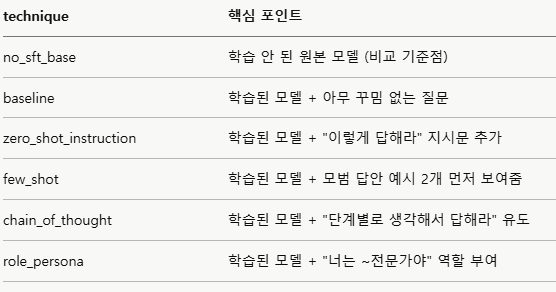

In [31]:
import pandas as pd

df = pd.DataFrame(state['metrics']).T
df.index.name = 'technique'
print(df.round(3))

csv_path = os.path.join(PROJECT_DIR, 'metric_comparison.csv')
df.to_csv(csv_path, encoding='utf-8-sig')
print('결과표 저장 경로:', csv_path)

                       perplexity_mean  distinct_1_mean  distinct_2_mean  \
technique                                                                  
baseline                        10.132            0.953            0.997   
zero_shot_instruction            8.413            0.987            1.000   
few_shot                         7.060            0.974            1.000   
chain_of_thought                11.300            0.966            1.000   
role_persona                     9.186            0.959            0.993   
no_sft_base                     39.770            0.980            1.000   

                       relevance_mean  rouge_l_vs_baseline_mean  
technique                                                        
baseline                        0.596                     0.800  
zero_shot_instruction           0.416                     0.321  
few_shot                        0.272                     0.291  
chain_of_thought                0.606                     0.4

[Perplexity: 낮을수록 자연스러운 문장]
- no_sft_base(SFT 적용 전)의 perplexity가 39,770으로, SFT 적용 후 모든 조건(7천-1만대)에서 4-6배 이상 낮음
- 이것은 SFT 적용 전/후 비교에서 SFT 적용 후 더 자연스러운 한국어 문장을 생성한 것을 잘 보여줌

[Distinct-1 / Distinct-2 :표현 다양성]
- 답변 길이가 150 토큰 이내로 짧다 보니 반복 표현이 나올 여지가 적어서 거의 고유한 n-gram으로 나온 것으로 보임

[relevance: 질문-답변 관련도]
- relevance에서 trade-off가 보임
- few_shot은 perplexity 기준 가장 자연스러운 문장을 만들지만 질문과 관련도는 가장 낮음
- 반대로 chain_of_thought는 문장 자연스러움은 조금 떨어져도 질문에 가장 밀접하게 답함
- no_sft_base가 관련도도 가장 낮다는 점 역시 SFT 이전 모델은 질문에 맞는 답을 만드는 능력이 약함을 보여줌

[ROUGE-L vs baseline:SFT baseline 답변과 텍스트 겹침 정도]
- no_sft_base가 0.019로 0에 가깝고, 이는 SFT 적용 후 baseline 답변과 텍스트 구조/어휘가 완전히 다르다는 의미로 SFT 학습이 모델의 답변 스타일 자체를 크게 바꿨다는 뜻

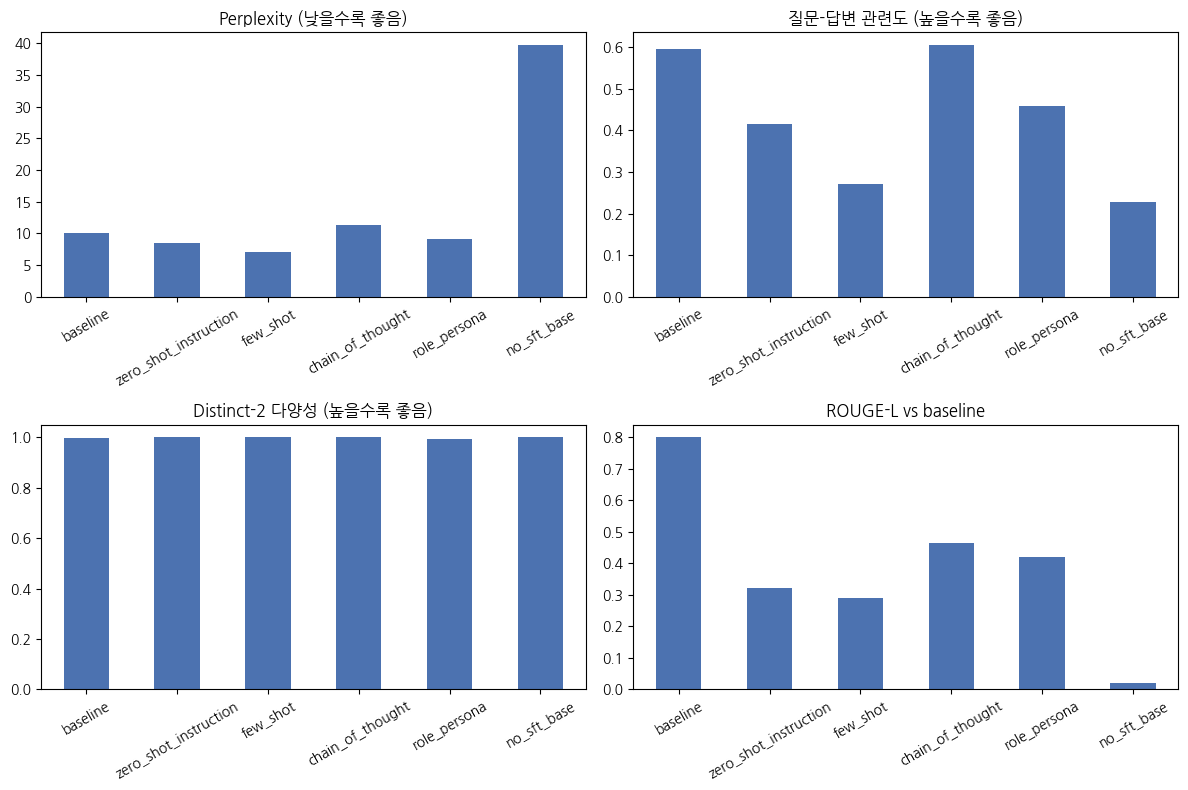

그래프 저장 경로: /content/drive/MyDrive/KoChatGPT_upgrade/metric_comparison.png


In [32]:
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['axes.unicode_minus'] = False
!apt-get -y install fonts-nanum > /dev/null 2>&1
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
metrics_to_plot = ['perplexity_mean', 'relevance_mean', 'distinct_2_mean', 'rouge_l_vs_baseline_mean']
titles = ['Perplexity (낮을수록 좋음)', '질문-답변 관련도 (높을수록 좋음)',
          'Distinct-2 다양성 (높을수록 좋음)', 'ROUGE-L vs baseline']

for ax, metric, title in zip(axes.flat, metrics_to_plot, titles):
    df[metric].plot(kind='bar', ax=ax, color='#4C72B0')
    ax.set_title(title)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
fig_path = os.path.join(PROJECT_DIR, 'metric_comparison.png')
plt.savefig(fig_path, dpi=150)
plt.show()
print('그래프 저장 경로:', fig_path)

10. 답변 예시 비교

In [34]:
for question in state['questions']:
    print("=" * 80)
    print(f"질문: {question}")
    print("=" * 80)

    print(f"\n[SFT 적용 전 (base, 프롬프팅 없음)]")
    print(state['generations']['no_sft_base'][question])

    for technique in TECHNIQUES:
        print(f"\n[SFT 적용 후 - {technique}]")
        print(state['generations'][technique][question])

    print()

질문: 건강하게 살을 빼는 방법을 알려줘.

[SFT 적용 전 (base, 프롬프팅 없음)]
인천지방법원 형사4단독 김형남 판사는 상해·욕망·폭행 혐의로 기소된 A(25) 씨에게 징역 1년에 집행유예 2년, 벌금 200만 원을 선고했다고 20일 밝혔다.
A 씨는 지난 4월 21일 오후 10시께 인천 부평구의 한 도로에서 B(21·여) 씨가 운전하는 차량을 발견하고 욕설하고 난동을 피워 약 1분여 간 폭행을 가한 혐의를 받는다.
경찰 조사결과 피해자는 자신의 차를 몰고 다른 길을 가려고 하자 이 같은 범행으로 이어졌다.
B 씨는 만취 상태였던 것으로 확인됐다.
당시 경찰은 "차가 고장 나 있다"고 112에 신고했지만 출동한 경찰에 의해 신고를 하지 않았다.
이후 차량 운전자 김씨는 인근 파출소에 찾아가 "운전석에 앉아 있던 여자가

[SFT 적용 후 - baseline]
'1. 충분한 수면과 영양소를 섭취해 체중 감량에 도움을 주는 음식\n2. 식습관을 개선하여 체중을 줄여주는 식품\n3. 규칙적인 운동도 중요합니다. 건강한 생활 습관과 꾸준한 운동은 건강한 삶을 유지할 수 있는 좋은 방법입니다.\n4. 스트레스를 줄이는 법도 있습니다. 스트레스는 우리 몸을 압박하고, 암과 같은 면역 질환에 대한 공격을 가하기 때문입니다.\n5. 적절한 운동을 통해 건강을 유지하는 것도 중요합니다. 건강한 라이프 스타일과 운동 습관을 유지함으로써 불필요한 긴장이나 불안감을 줄일 수 있으며, 이를 통해 몸 상태를 안정시킬 수도 있습니다.

[SFT 적용 후 - zero_shot_instruction]
'1. 건강한 식습관 유지\n2. 충분한 수면 & 운동\n3. 꾸준한 운동, 올바른 식사 습관 유지\n4. 영양소 섭취 및 균형 있는 생활 습관을 갖는 것 등이 도움이 됩니다.\n\n5. 일상 생활에서 스트레스 해소하기\n6. 새로운 취미나 스포츠 활동 참여\n7. 건강과 체력 관리 등 건강 유지에 필요한 활동에 대한 정보도 제공해 주세요.

[SFT 적용 후 - few_shot]


In [35]:
question = state['questions'][0]
print(f"질문: {question}\n")
print("[SFT 적용 전]", state['generations']['no_sft_base'][question], "\n")
for technique in TECHNIQUES:
    print(f"[{technique}]", state['generations'][technique][question], "\n")

질문: 건강하게 살을 빼는 방법을 알려줘.

[SFT 적용 전] 인천지방법원 형사4단독 김형남 판사는 상해·욕망·폭행 혐의로 기소된 A(25) 씨에게 징역 1년에 집행유예 2년, 벌금 200만 원을 선고했다고 20일 밝혔다.
A 씨는 지난 4월 21일 오후 10시께 인천 부평구의 한 도로에서 B(21·여) 씨가 운전하는 차량을 발견하고 욕설하고 난동을 피워 약 1분여 간 폭행을 가한 혐의를 받는다.
경찰 조사결과 피해자는 자신의 차를 몰고 다른 길을 가려고 하자 이 같은 범행으로 이어졌다.
B 씨는 만취 상태였던 것으로 확인됐다.
당시 경찰은 "차가 고장 나 있다"고 112에 신고했지만 출동한 경찰에 의해 신고를 하지 않았다.
이후 차량 운전자 김씨는 인근 파출소에 찾아가 "운전석에 앉아 있던 여자가 

[baseline] '1. 충분한 수면과 영양소를 섭취해 체중 감량에 도움을 주는 음식\n2. 식습관을 개선하여 체중을 줄여주는 식품\n3. 규칙적인 운동도 중요합니다. 건강한 생활 습관과 꾸준한 운동은 건강한 삶을 유지할 수 있는 좋은 방법입니다.\n4. 스트레스를 줄이는 법도 있습니다. 스트레스는 우리 몸을 압박하고, 암과 같은 면역 질환에 대한 공격을 가하기 때문입니다.\n5. 적절한 운동을 통해 건강을 유지하는 것도 중요합니다. 건강한 라이프 스타일과 운동 습관을 유지함으로써 불필요한 긴장이나 불안감을 줄일 수 있으며, 이를 통해 몸 상태를 안정시킬 수도 있습니다. 

[zero_shot_instruction] '1. 건강한 식습관 유지\n2. 충분한 수면 & 운동\n3. 꾸준한 운동, 올바른 식사 습관 유지\n4. 영양소 섭취 및 균형 있는 생활 습관을 갖는 것 등이 도움이 됩니다.\n\n5. 일상 생활에서 스트레스 해소하기\n6. 새로운 취미나 스포츠 활동 참여\n7. 건강과 체력 관리 등 건강 유지에 필요한 활동에 대한 정보도 제공해 주세요. 

[few_shot] '1. 건강한 식습관을 유지하기 위해 물을 자주 마시는 것이 좋습니다.\n2. 적절

[회고]

오늘 작업 내용:
- KoChatGPT 개선 전략 중 전략 2(정량적 평가 메트릭 도입)와 전략 3(Instruction Tuning / Prompting 기법 적용)을 진행함
- KoGPT-2를 파인튜닝 SFT함 (전체 12,000개 데이터, 2 epoch)
- 학습된 SFT 모델에 5가지 프롬프팅 기법(baseline, zero-shot instruction, few-shot, chain-of-thought, role-persona)을 적용하고 답변 생성
- Perplexity·Distinct-n·임베딩 기반 관련도·ROUGE-L 4개 정량 지표로 비교
- 평가기준 충족을 위해 SFT 적용 전(base 모델) vs 적용 후 모델의 성능도 별도로 비교함

오늘의 어려움:
- transformers 라이브러리 버전이 의도치 않게 최신(5.x)으로 바뀌면서 TrainingArguments API 호환 문제로 한국어 디코딩이 통째로 깨지는(◆ 문자) 근본 원인으로 이어짐
- GPU 메모리 부족(OOM), Google Drive 저장 용량 초과
- 토크나이저가 깨진 상태로 진행된 SFT 학습 결과물이 무효화되어 재학습 진행  

오늘의 교훈:
- 딥러닝 코드 자체보다 라이브러리 버전 관리의 중요성을 실감
- SFT 적용 전/후 Perplexity가 3.5~5.6배 개선되고 질문-답변 관련도도 2배 이상 상승해, SFT의 효과를 수치로 확인
- 반면 프롬프팅 기법 간에는 few-shot(유창함 우수) vs chain-of-thought(질문 충실도 우수)처럼 지표 간 트레이드오프가 있어, 무조건 좋은 기법은 없고 목적에 따라 선택을 다르게 해야한다는 것을 확인